### Install libraries

In [1]:
# Install required packages
!pip install tensorflow[and-cuda] --upgrade
!pip install numpy scikit-learn tensorboard matplotlib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


### Check for GPU availability

In [2]:
import tensorflow as tf

2025-12-11 11:49:17.455216: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

### Import all libraries

In [4]:
# Now import everything
import os
import io
import itertools

import numpy as np
import sklearn.metrics
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorboard.plugins.hparams import api as hp

In [5]:
print("TensorFlow version:", tf.__version__)
print("Num GPUs available:", len(tf.config.list_physical_devices('GPU')))
print("All packages installed and imported successfully!")

TensorFlow version: 2.20.0
Num GPUs available: 1
All packages installed and imported successfully!


### Change working directory

In [6]:
# project_dir = os.path.join(os.getcwd(), "smartClothClassifier")
import os

project_dir = os.path.expanduser("~/miniconda3/qadeem/completeAI/roboflow_download")

if os.path.exists(project_dir):
    os.chdir(project_dir)
    print("Directory changed to:", os.getcwd())
else:
    print("Path does not exist:", project_dir)


Directory changed to: /home/masters/miniconda3/qadeem/completeAI/roboflow_download


In [7]:
import os

project_dir = os.path.expanduser("~/miniconda3/qadeem/completeAI/roboflow_download")
os.chdir(project_dir)

print(os.getcwd())


/home/masters/miniconda3/qadeem/completeAI/roboflow_download


### Import dataset

In [8]:
# Image size for all models
IMG_SIZE = 224
BATCH_SIZE = 32

# Load train/val/test datasets directly from Roboflow folders
train_ds = tf.keras.utils.image_dataset_from_directory(
    "train",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "valid",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "test",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 10263 files belonging to 4 classes.


I0000 00:00:1765450173.574731   10540 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14268 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 738 files belonging to 4 classes.
Found 732 files belonging to 4 classes.


In [9]:
# Normalize on the fly instead of dividing huge arrays manually
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(normalize)
val_ds = val_ds.map(normalize)
test_ds = test_ds.map(normalize)

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


2025-12-11 11:51:30.836376: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-12-11 11:51:30.836463: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


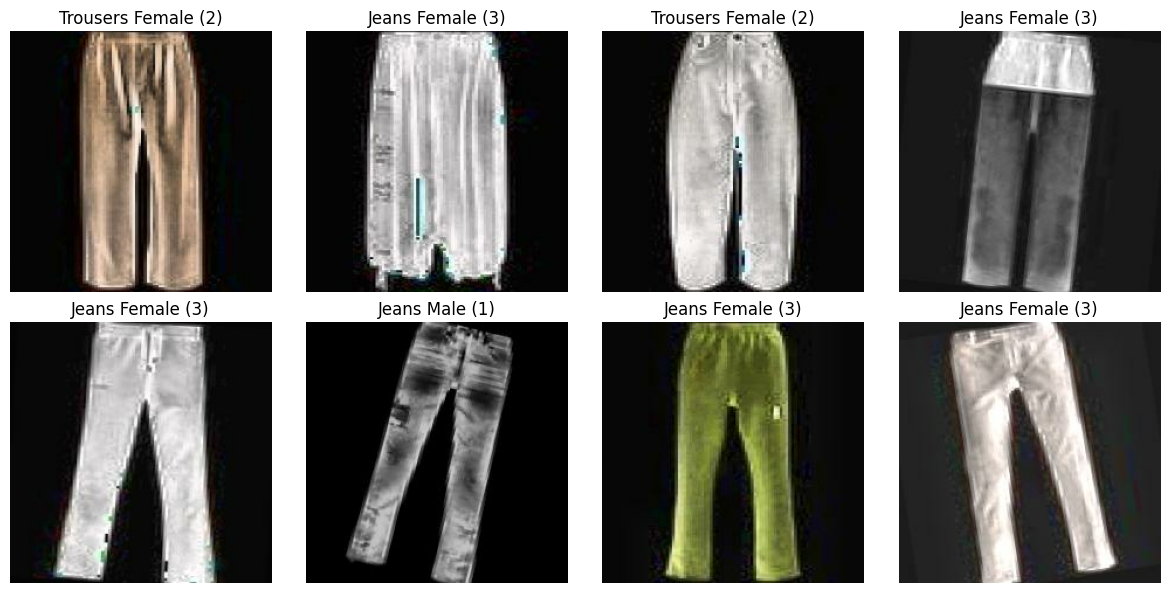

In [11]:
# Get one batch from the train dataset
for images_batch, labels_batch in train_ds.take(1):
    images_to_show = images_batch.numpy()
    labels_to_show = labels_batch.numpy()
    break

# Randomly select 8 images from this batch
num_images = 8
indices = np.random.choice(len(images_to_show), size=num_images, replace=False)
images_to_show = images_to_show[indices]
labels_to_show = labels_to_show[indices]

# Define class names
class_names = ['Trousers Male', 'Jeans Male', 'Trousers Female', 'Jeans Female']

# Create a 2-row, 4-column plot
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for img, label, ax in zip(images_to_show, labels_to_show, axes):
    ax.imshow(img)
    ax.set_title(f"{class_names[label]} ({label})")
    ax.axis('off')

plt.tight_layout()
plt.show()

### Defining the hyperparameters we would tune, and their values to be tested

In [12]:
HP_FILTER_SIZE_1 = hp.HParam('filter_size_1', hp.Discrete([3,5]))
HP_FILTER_NUM = hp.HParam('filters_number', hp.Discrete([32,64]))
HP_FILTER_SIZE_2 = hp.HParam('filter_size_2', hp.Discrete([3,5]))
HP_DENSE_SIZE = hp.HParam('dense_size', hp.Discrete([256,512]))

METRIC_ACCURACY = 'accuracy'
EPOCHS = 100

# Logging setup info
with tf.summary.create_file_writer(r'logs/model/hparam_tuning/').as_default():
    hp.hparams_config(
        hparams=[HP_FILTER_SIZE_1, HP_FILTER_NUM, HP_FILTER_SIZE_2, HP_DENSE_SIZE],
        metrics=[hp.Metric(METRIC_ACCURACY, display_name='Accuracy')],
    )

### Helper functions

In [13]:
def plot_confusion_matrix(cm, class_names):
    """
    Returns a matplotlib figure containing the plotted confusion matrix.

    Args:
      cm (array, shape = [n, n]): a confusion matrix of integer classes
      class_names (array, shape = [n]): String names of the integer classes
    """
    figure = plt.figure(figsize=(12, 12))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    # Normalize the confusion matrix.
    cm = np.around(cm.astype('float') / cm.sum(axis=1)[:, np.newaxis], decimals=2)

    # Use white text if squares are dark; otherwise black.
    threshold = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        color = "white" if cm[i, j] > threshold else "black"
        plt.text(j, i, cm[i, j], horizontalalignment="center", color=color)

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    return figure

def plot_to_image(figure):
    """Converts the matplotlib plot specified by 'figure' to a PNG image and
    returns it. The supplied figure is closed and inaccessible after this call."""
    # Save the plot to a PNG in memory.
    buf = io.BytesIO()
    plt.savefig(buf, format='png')
    # Closing the figure prevents it from being displayed directly inside
    # the notebook.
    plt.close(figure)
    buf.seek(0)
    # Convert PNG buffer to TF image
    image = tf.image.decode_png(buf.getvalue(), channels=4)
    # Add the batch dimension
    image = tf.expand_dims(image, 0)
    return image


### Custom Models

### Custom Model Definition

In [14]:
def train_test_custom_model(hparams, session_num):

    # Outlining the model/architecture of our CNN
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(224, 224, 3)),
        tf.keras.layers.Conv2D(hparams[HP_FILTER_NUM], hparams[HP_FILTER_SIZE_1], activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
        tf.keras.layers.Conv2D(hparams[HP_FILTER_NUM], hparams[HP_FILTER_SIZE_2], activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(hparams[HP_DENSE_SIZE], activation='relu'),
        tf.keras.layers.Dense(4)
    ])

    # Defining the loss function
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    # Compiling the model
    model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])

    # Defining the logging directory
    log_dir = r"logs/model/fit/" + "run-{}".format(session_num)
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, profile_batch=0)


    # Defining a file writer for Confusion Matrix logging purposes
    file_writer_cm = tf.summary.create_file_writer(log_dir + '/cm')

    def log_custom_model_confusion_matrix_ds(model, dataset, file_writer_cm, class_names):
        """
        Returns a callback function that logs the confusion matrix to TensorBoard.
        Works with tf.data.Dataset objects.
        """
        def callback(epoch, logs):
            y_true = []
            y_pred = []
    
            for images, labels in dataset:
                preds = model.predict(images, verbose=0)
                preds = np.argmax(preds, axis=1)
                y_pred.extend(preds)
                y_true.extend(labels.numpy())
    
            cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
    
            # Plot and log
            fig = plot_confusion_matrix(cm, class_names)
            cm_image = plot_to_image(fig)
    
            with file_writer_cm.as_default():
                tf.summary.image("Confusion Matrix", cm_image, step=epoch)
    
        return tf.keras.callbacks.LambdaCallback(on_epoch_end=callback)

    cm_callback = log_custom_model_confusion_matrix_ds(
    model=model,
    dataset=val_ds,
    file_writer_cm=file_writer_cm,
    class_names=['Trousers Male', 'Jeans Male', 'Trousers Female', 'Jeans Female'])

    # Defining early stopping to prevent overfitting
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        mode = 'auto',
        min_delta = 0,
        patience = 5,
        verbose = 0,
        restore_best_weights = True
    )

    # Training the model
    # model.fit(
    #     images_train,
    #     labels_train,
    #     epochs = EPOCHS,
    #     batch_size = BATCH_SIZE,
    #     callbacks = [tensorboard_callback, cm_callback, early_stopping],
    #     validation_data = (images_val,labels_val),
    #     verbose = 2
    # )

    model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        callbacks=[tensorboard_callback, cm_callback, early_stopping],
        verbose=2
    )

    
    # Evaluating the model's performance on the validation set
    # _, accuracy = model.evaluate(images_val,labels_val)
    _, accuracy = model.evaluate(val_ds)

    os.makedirs("saved_models", exist_ok=True)

    # Saving the current model for future reference
    model.save(r"saved_models/Run-{}.keras".format(session_num))

    return accuracy

### Create a function to log the result of the custom model

In [15]:
# Creating a function to log the results
def run(log_dir, hparams, session_num):

    with tf.summary.create_file_writer(log_dir).as_default():
        hp.hparams(hparams)  # record the values used in this trial
        accuracy = train_test_custom_model(hparams, session_num)
        tf.summary.scalar(METRIC_ACCURACY, accuracy, step=1)

### Train custom model

In [16]:
session_num = 1

for filter_size_1 in HP_FILTER_SIZE_1.domain.values:
    for filter_num in HP_FILTER_NUM.domain.values:
        for filter_size_2 in HP_FILTER_SIZE_2.domain.values:
            for dense_size in HP_DENSE_SIZE.domain.values:

                hparams = {
                    HP_FILTER_SIZE_1: filter_size_1,
                    HP_FILTER_NUM: filter_num,
                    HP_FILTER_SIZE_2: filter_size_2,
                    HP_DENSE_SIZE: dense_size
                }

                run_name = "run-%d" % session_num
                print('--- Starting trial: %s' % run_name)
                print({h.name: hparams[h] for h in hparams})
                run(r'logs/model/hparam_tuning/' + run_name, hparams, session_num)

                session_num += 1

--- Starting trial: run-1
{'filter_size_1': 3, 'filters_number': 32, 'filter_size_2': 3, 'dense_size': 256}


/home/masters/.local/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100


2025-12-11 11:56:10.698882: I external/local_xla/xla/service/service.cc:163] XLA service 0x7dc59c009610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-11 11:56:10.698893: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A4000, Compute Capability 8.6
2025-12-11 11:56:10.727257: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-11 11:56:10.866636: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-12-11 11:56:11.315761: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_471', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1765450573.849806   10768 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most onc

321/321 - 19s - 60ms/step - accuracy: 0.5670 - loss: 1.0738 - val_accuracy: 0.6775 - val_loss: 0.7924
Epoch 2/100


...

321/321 - 33s - 102ms/step - accuracy: 0.5742 - loss: 1.0913 - val_accuracy: 0.6843 - val_loss: 0.8061
Epoch 2/100
321/321 - 19s - 58ms/step - accuracy: 0.6900 - loss: 0.7561 - val_accuracy: 0.7005 - val_loss: 0.7075
Epoch 3/100
321/321 - 19s - 60ms/step - accuracy: 0.7448 - loss: 0.6322 - val_accuracy: 0.7371 - val_loss: 0.6960
Epoch 4/100
321/321 - 19s - 60ms/step - accuracy: 0.7916 - loss: 0.5281 - val_accuracy: 0.7222 - val_loss: 0.7201
Epoch 5/100
321/321 - 19s - 60ms/step - accuracy: 0.8356 - loss: 0.4208 - val_accuracy: 0.7425 - val_loss: 0.7065
Epoch 6/100
321/321 - 19s - 59ms/step - accuracy: 0.8814 - loss: 0.3175 - val_accuracy: 0.7534 - val_loss: 0.7653
Epoch 7/100
321/321 - 19s - 59ms/step - accuracy: 0.9155 - loss: 0.2221 - val_accuracy: 0.7493 - val_loss: 0.8426
Epoch 8/100
321/321 - 19s - 59ms/step - accuracy: 0.9445 - loss: 0.1576 - val_accuracy: 0.7439 - val_loss: 0.9964
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7371 - loss: 0.6960
--- Starting trial: run-16

/home/masters/.local/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


321/321 - 35s - 110ms/step - accuracy: 0.5528 - loss: 1.0435 - val_accuracy: 0.6734 - val_loss: 0.7972
Epoch 2/100
321/321 - 32s - 99ms/step - accuracy: 0.6826 - loss: 0.7854 - val_accuracy: 0.7236 - val_loss: 0.7038
Epoch 3/100
321/321 - 30s - 93ms/step - accuracy: 0.7305 - loss: 0.6551 - val_accuracy: 0.7385 - val_loss: 0.6764
Epoch 4/100
321/321 - 33s - 104ms/step - accuracy: 0.7922 - loss: 0.5265 - val_accuracy: 0.7480 - val_loss: 0.6795
Epoch 5/100
321/321 - 38s - 118ms/step - accuracy: 0.8456 - loss: 0.4012 - val_accuracy: 0.7737 - val_loss: 0.6439
Epoch 6/100
321/321 - 35s - 109ms/step - accuracy: 0.8895 - loss: 0.2828 - val_accuracy: 0.7412 - val_loss: 0.8825
Epoch 7/100


2025-12-11 12:41:01.234163: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


321/321 - 31s - 95ms/step - accuracy: 0.9322 - loss: 0.1839 - val_accuracy: 0.7412 - val_loss: 0.9048
Epoch 8/100
321/321 - 31s - 97ms/step - accuracy: 0.9574 - loss: 0.1233 - val_accuracy: 0.7656 - val_loss: 1.1096
Epoch 9/100
321/321 - 30s - 93ms/step - accuracy: 0.9794 - loss: 0.0652 - val_accuracy: 0.7751 - val_loss: 1.1996
Epoch 10/100
321/321 - 32s - 98ms/step - accuracy: 0.9857 - loss: 0.0440 - val_accuracy: 0.7507 - val_loss: 1.3127
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7737 - loss: 0.6439


## Pretrained models

### Pretrained Model definition

In [17]:
def train_pretrained(model_name, base_model, train_ds, val_ds, class_names):
    print(f"\n================== {model_name} TRAINING ==================")

    # Freeze base model for transfer learning
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dense(len(class_names), activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # -------------------------
    # Logging directories
    # -------------------------
    log_dir = f"logs/pretrained/{model_name}"
    os.makedirs(log_dir, exist_ok=True)

    tb_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
    file_writer_cm = tf.summary.create_file_writer(log_dir + "/cm")

    # -------------------------
    # Confusion Matrix Callback
    # -------------------------
    def cm_callback_fn(epoch, logs):
        y_true = []
        y_pred = []

        for images, labels in val_ds:
            preds = model.predict(images, verbose=0)
            preds = np.argmax(preds, axis=1)
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

        cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
        fig = plot_confusion_matrix(cm, class_names)
        cm_image = plot_to_image(fig)

        with file_writer_cm.as_default():
            tf.summary.image("Confusion Matrix", cm_image, step=epoch)

    cm_callback = tf.keras.callbacks.LambdaCallback(on_epoch_end=cm_callback_fn)

    # -------------------------
    # Early Stopping
    # -------------------------
    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    )

    # -------------------------
    # TRAINING
    # -------------------------
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[tb_callback, cm_callback, early],
        verbose=2
    )

    # Evaluate on validation set
    _, accuracy = model.evaluate(val_ds)

    # -------------------------
    # SAVE MODEL
    # -------------------------
    save_dir = "saved_models/pretrained"
    os.makedirs(save_dir, exist_ok=True)
    save_path = f"{save_dir}/{model_name}.keras"
    model.save(save_path)
    print(f"{model_name} saved to {save_path}")

    return model, accuracy


### Pretrained model training

In [18]:
# MobileNetV2
mobilenet_base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
model_mobilenet, mobilenet_accuracy = train_pretrained(
    "MobileNetV2", mobilenet_base, train_ds, val_ds, class_names
)

# ResNet50
resnet_base = tf.keras.applications.ResNet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
model_resnet, resnet_accuracy = train_pretrained(
    "ResNet50", resnet_base, train_ds, val_ds, class_names
)



================== MobileNetV2 TRAINING ==================
Epoch 1/100


2025-12-11 12:42:45.168705: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-11 12:42:45.849664: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6321', 4 bytes spill stores, 4 bytes spill loads

2025-12-11 12:42:46.147229: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6321', 520 bytes spill stores, 520 bytes spill loads

2025-12-11 12:42:48.307219: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, ple

321/321 - 32s - 101ms/step - accuracy: 0.6381 - loss: 0.8686 - val_accuracy: 0.7304 - val_loss: 0.6965
Epoch 2/100
321/321 - 8s - 24ms/step - accuracy: 0.7460 - loss: 0.6455 - val_accuracy: 0.7466 - val_loss: 0.6390
Epoch 3/100
321/321 - 8s - 23ms/step - accuracy: 0.7765 - loss: 0.5720 - val_accuracy: 0.7480 - val_loss: 0.6119
Epoch 4/100
321/321 - 8s - 25ms/step - accuracy: 0.8025 - loss: 0.5201 - val_accuracy: 0.7724 - val_loss: 0.5786
Epoch 5/100
321/321 - 8s - 24ms/step - accuracy: 0.8194 - loss: 0.4799 - val_accuracy: 0.7696 - val_loss: 0.5767
Epoch 6/100
321/321 - 7s - 23ms/step - accuracy: 0.8339 - loss: 0.4438 - val_accuracy: 0.7724 - val_loss: 0.5467
Epoch 7/100
321/321 - 7s - 22ms/step - accuracy: 0.8460 - loss: 0.4155 - val_accuracy: 0.7575 - val_loss: 0.5794
Epoch 8/100
321/321 - 7s - 22ms/step - accuracy: 0.8575 - loss: 0.3903 - val_accuracy: 0.7669 - val_loss: 0.5578
Epoch 9/100
321/321 - 7s - 22ms/step - accuracy: 0.8685 - loss: 0.3708 - val_accuracy: 0.7886 - val_loss: 

2025-12-11 12:45:12.690066: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-11 12:45:13.312810: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7803', 4 bytes spill stores, 4 bytes spill loads

2025-12-11 12:45:13.505417: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7803', 520 bytes spill stores, 520 bytes spill loads



321/321 - 43s - 132ms/step - accuracy: 0.3153 - loss: 1.3739 - val_accuracy: 0.4051 - val_loss: 1.3233
Epoch 2/100
321/321 - 16s - 50ms/step - accuracy: 0.4028 - loss: 1.3094 - val_accuracy: 0.4702 - val_loss: 1.2704
Epoch 3/100
321/321 - 16s - 50ms/step - accuracy: 0.4360 - loss: 1.2677 - val_accuracy: 0.4295 - val_loss: 1.2513
Epoch 4/100
321/321 - 16s - 50ms/step - accuracy: 0.4746 - loss: 1.2300 - val_accuracy: 0.4675 - val_loss: 1.2090
Epoch 5/100
321/321 - 16s - 50ms/step - accuracy: 0.4819 - loss: 1.2030 - val_accuracy: 0.5068 - val_loss: 1.1711
Epoch 6/100
321/321 - 16s - 51ms/step - accuracy: 0.4864 - loss: 1.1789 - val_accuracy: 0.5149 - val_loss: 1.1421
Epoch 7/100
321/321 - 16s - 50ms/step - accuracy: 0.4960 - loss: 1.1625 - val_accuracy: 0.4959 - val_loss: 1.1525
Epoch 8/100
321/321 - 16s - 50ms/step - accuracy: 0.5091 - loss: 1.1454 - val_accuracy: 0.5190 - val_loss: 1.1237
Epoch 9/100
321/321 - 16s - 50ms/step - accuracy: 0.5144 - loss: 1.1320 - val_accuracy: 0.5325 - va

In [20]:
# Loading a model to evaluate on the test set
custom_model = tf.keras.models.load_model(r"/home/masters/miniconda3/qadeem/completeAI/roboflow_download/saved_models/Run-15.keras")
mobilenet_model = tf.keras.models.load_model(r"/home/masters/miniconda3/qadeem/completeAI/roboflow_download/saved_models/pretrained/MobileNetV2.keras")
resnet50_model = tf.keras.models.load_model(r"/home/masters/miniconda3/qadeem/completeAI/roboflow_download/saved_models/pretrained/ResNet50.keras")
effnet_model = tf.keras.models.load_model(r"/home/masters/miniconda3/qadeem/completeAI/roboflow_download/saved_models/pretrained/EfficientNetB0.keras")

In [21]:
%load_ext tensorboard


### 

In [22]:
%tensorboard --logdir logs